Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape: (10000,)
Label(y_train[0]) corresponds to category: Ankle Boot
Label(y_train[1]) corresponds to category: T-shirt/top
Label(y_train[2]) corresponds to category: T-shirt/top
Label(y_train[3]) corresponds to category: Dress
Label(y_train[4]) corresponds to category: T-shirt/top
Label(y_train[5]) corresponds to category: Pullover
Label(y_train[6]) corresponds to category: Sneaker
Label(y_train[7]) corresponds to category: Pullover
Label(y_train[8]) corresponds to category: Sandal
Label(y_train[9]) corresponds to category: Sandal


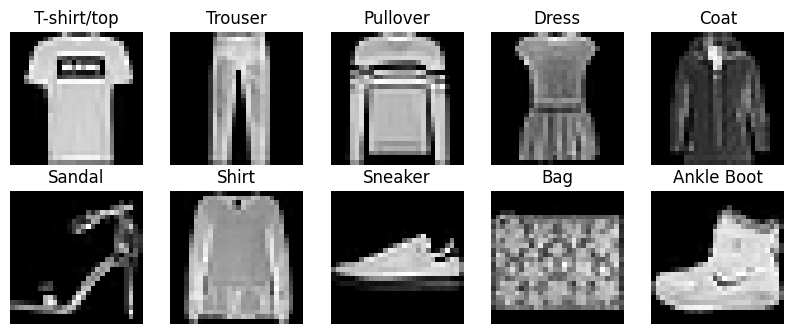

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7821 - loss: 0.6261 - val_accuracy: 0.8431 - val_loss: 0.4429
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8603 - loss: 0.3855 - val_accuracy: 0.8617 - val_loss: 0.3962
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8786 - loss: 0.3361 - val_accuracy: 0.8636 - val_loss: 0.3756
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8839 - loss: 0.3143 - val_accuracy: 0.8619 - val_loss: 0.3705
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8878 - loss: 0.3031 - val_accuracy: 0.8772 - val_loss: 0.3477
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8969 - loss: 0.2812 - val_accuracy: 0.8736 - val_loss: 0.3493
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9004 - loss: 0.2685 - val_accuracy: 0.8764 - val_loss: 0.3482
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9015 - loss: 0.2600 - 

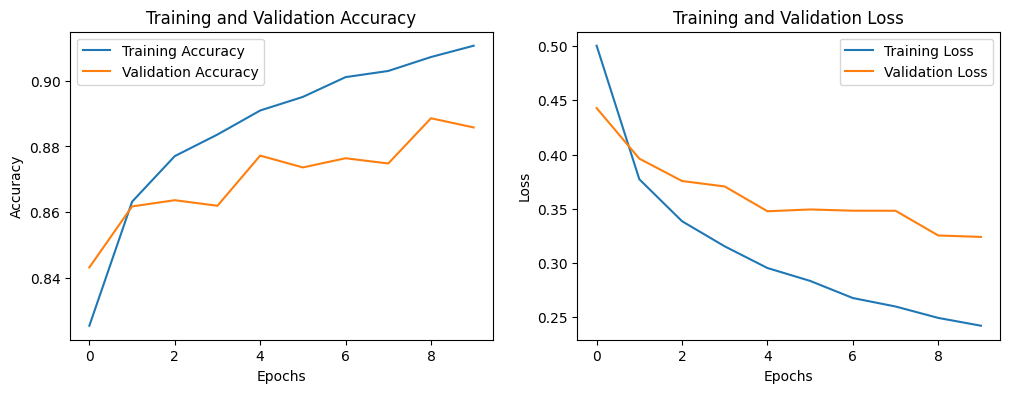

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)
category_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']
for i in range(10):
    print(f'Label(y_train[{i}]) corresponds to category: {category_names[y_train[i]]}')
plt.figure(figsize=(10,10))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(category_names[i])
    plt.axis('off')
plt.show()
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(120, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
